# Predicción de Rotación de Personal (Employee Attrition)
### Ejercicio Práctico — Semana 1 | Máster en Data Science y Machine Learning

##### **Estudiantes.** Alexander Luna · Wilson Paredes · Alejandro Sarmiento · Diana Tandalla  -  Grupo 10

**Contexto.** Una empresa quiere anticipar qué empleados podrían dejar la organización.
Recursos Humanos tiene el historial de sus empleados, incluyendo quiénes se fueron
efectivamente (columna `Attrition`), pero hasta ahora ese dato solo se conoce después
de los hechos.

**Objetivo.** Entrenar y comparar varios modelos de clasificación y, sobre todo,
argumentar cuál conviene usar para este problema en particular — no necesariamente
el que saque el accuracy más alto.

**Dataset.** IBM HR Analytics Employee Attrition & Performance (1.470 registros, 35 variables).

---
## 0. Configuración del entorno

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)

print('Entorno listo.')

Entorno listo.


---
## 1. Exploración de los datos (EDA)

In [2]:
URL = ('https://raw.githubusercontent.com/IBM/employee-attrition-aif360/'
       'master/data/emp_attrition.csv')

try:
    df = pd.read_csv('hr.csv')          # copia local, si existe
except FileNotFoundError:
    df = pd.read_csv(URL)               # descarga directa

print(f'Registros: {df.shape[0]}   |   Variables: {df.shape[1]}')
df.head()

Registros: 1470   |   Variables: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
# Tipos de dato, nulos y cardinalidad
resumen = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isnull().sum(),
    'valores_unicos': df.nunique()
})
print('Total de valores nulos en el dataset:', df.isnull().sum().sum())
resumen

Total de valores nulos en el dataset: 0


,tipo,nulos,valores_unicos
Age,int64,0,43
Attrition,object,0,2
BusinessTravel,object,0,3
DailyRate,int64,0,886
Department,object,0,3
DistanceFromHome,int64,0,29
Education,int64,0,5
EducationField,object,0,6
EmployeeCount,int64,0,1
EmployeeNumber,int64,0,1470


### 1.1 ¿El dataset está balanceado?

Es la primera pregunta que hay que responder, porque de ella depende cómo se entrena
y, sobre todo, cómo se evalúa todo lo que viene después.

Attrition
No     1233
Yes     237

Attrition
No     83.88 %
Yes    16.12 %
Name: proportion, dtype: object

Ratio de desbalance: 1 salida por cada 5.2 permanencias


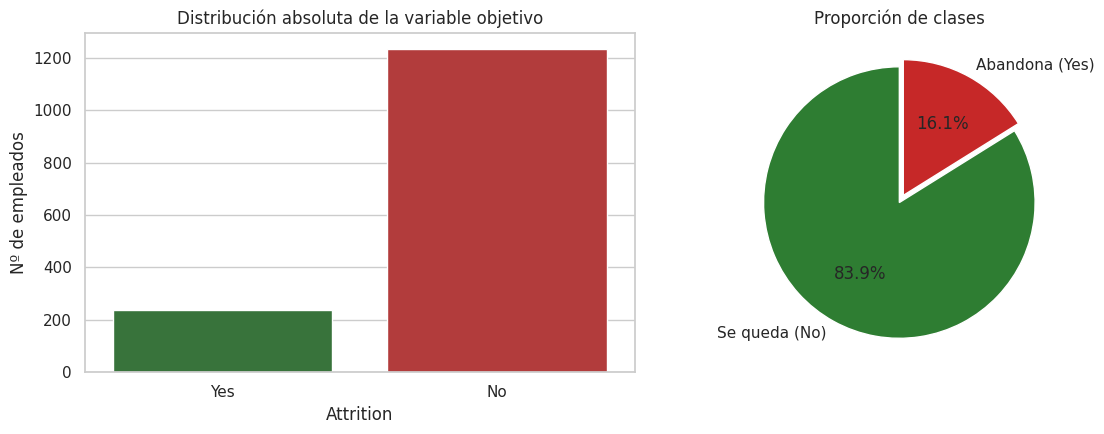

In [4]:
conteo = df['Attrition'].value_counts()
prop = df['Attrition'].value_counts(normalize=True)

print(conteo.to_string())
print()
print((prop * 100).round(2).astype(str) + ' %')
print(f'\nRatio de desbalance: 1 salida por cada {conteo["No"]/conteo["Yes"]:.1f} permanencias')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x='Attrition', data=df, ax=ax[0], palette=['#2e7d32', '#c62828'], hue='Attrition', legend=False)
ax[0].set_title('Distribución absoluta de la variable objetivo')
ax[0].set_ylabel('Nº de empleados')
ax[1].pie(conteo, labels=['Se queda (No)', 'Abandona (Yes)'], autopct='%1.1f%%',
          colors=['#2e7d32', '#c62828'], startangle=90, explode=(0, 0.06))
ax[1].set_title('Proporción de clases')
plt.tight_layout(); plt.show()

**No, está claramente desbalanceado.** Solo el 16,1 % de los empleados abandonó la
empresa (237 de 1.470) frente a un 83,9 % que se quedó — una proporción de
aproximadamente 1 a 5.

Esto tiene dos tipos de consecuencias. Para el **entrenamiento**: el algoritmo ve cinco
veces más ejemplos de "se queda", así que minimiza su función de pérdida siendo
conservador y termina aprendiendo a predecir la clase mayoritaria por defecto, ignorando
el patrón minoritario que es justamente el que le interesa a RR.HH. Los modelos con más
capacidad (Random Forest, Gradient Boosting) son especialmente propensos a esto si no se
corrige el desbalance.

Para la **evaluación**, el problema es que el accuracy queda inflado y deja de decir
nada útil: un clasificador que prediga "nadie se va" para todos acierta el 83,9 % de las
veces sin haber aprendido absolutamente nada. Ese es el verdadero *baseline* — no el
50 % que uno asumiría de entrada — y hay que evaluar con Recall, Precision, F1 y ROC-AUC
sobre la clase positiva (`Attrition = Yes`), además de estratificar la partición
train/test para que ambos conjuntos conserven la proporción original.

Existen varias formas de corregir el desbalance: `class_weight='balanced'` (repondera la
función de pérdida), sobremuestreo tipo SMOTE, submuestreo de la clase mayoritaria o
ajuste del umbral de decisión. Aquí usamos las dos primeras opciones de esta lista que no
alteran artificialmente la distribución real de los datos: ponderación de clases y
ajuste de umbral.

### 1.2 Variables numéricas frente a la rotación

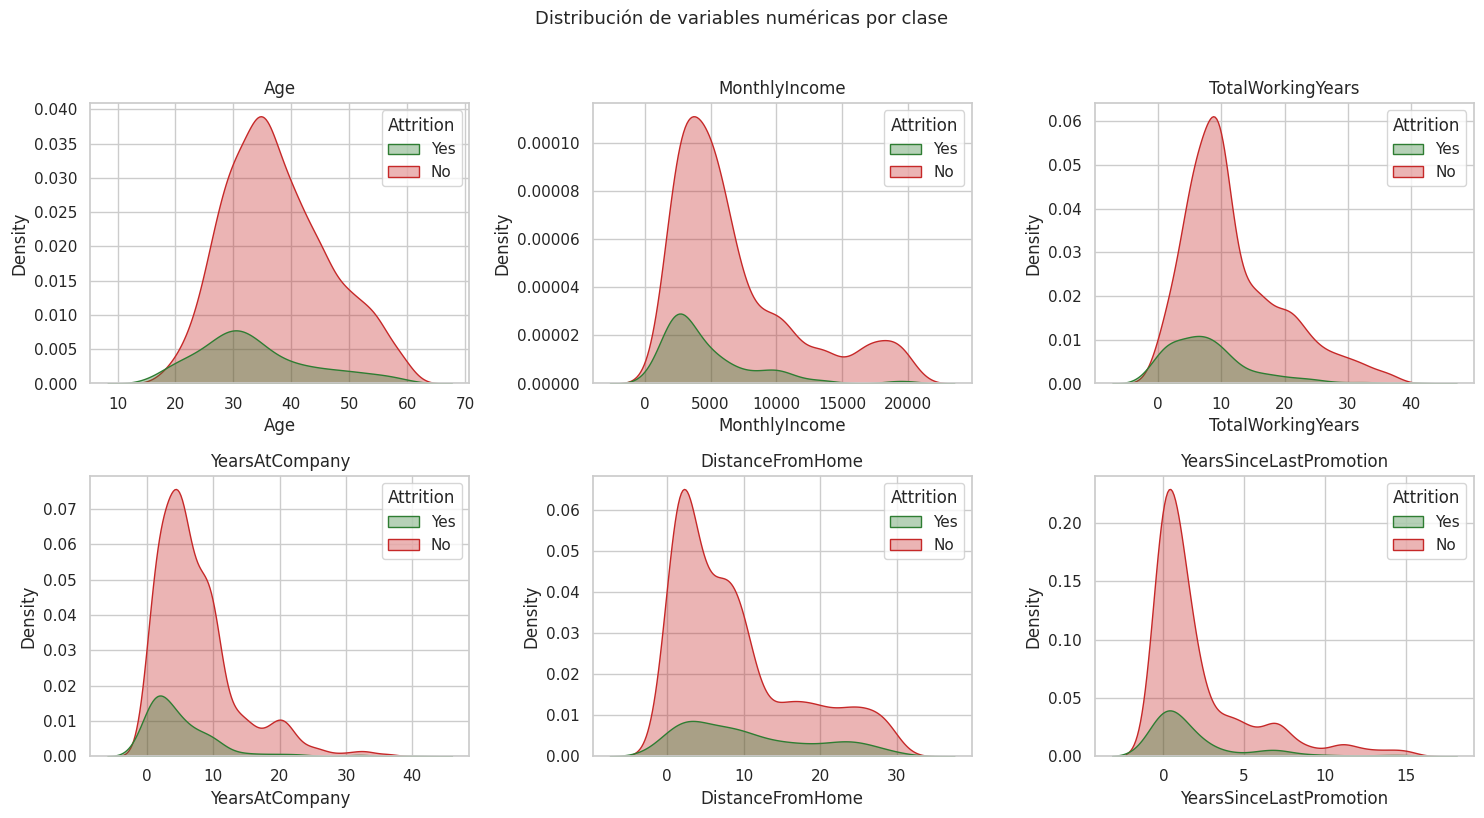

In [5]:
num_interes = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
               'DistanceFromHome', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_interes):
    sns.kdeplot(data=df, x=col, hue='Attrition', fill=True, alpha=.35,
                palette=['#2e7d32', '#c62828'], ax=ax)
    ax.set_title(col)
plt.suptitle('Distribución de variables numéricas por clase', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

### 1.3 Variables categóricas: tasa de rotación por grupo

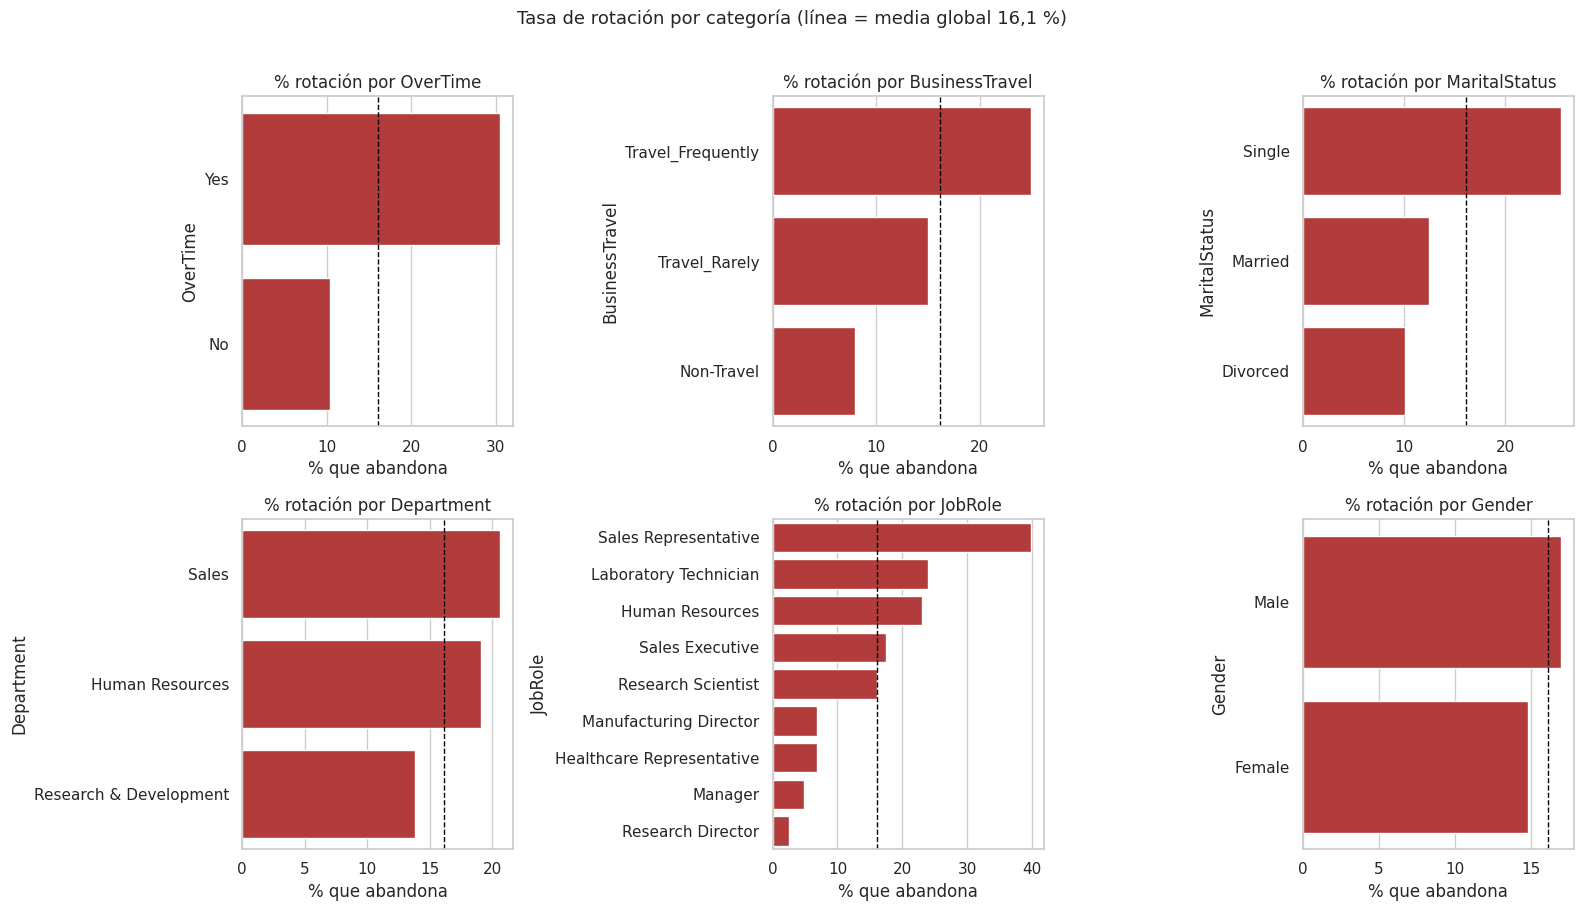

In [6]:
cat_interes = ['OverTime', 'BusinessTravel', 'MaritalStatus', 'Department',
               'JobRole', 'Gender']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), cat_interes):
    tasa = (df.groupby(col)['Attrition']
              .apply(lambda s: (s == 'Yes').mean() * 100)
              .sort_values(ascending=False))
    sns.barplot(x=tasa.values, y=tasa.index, ax=ax, color='#c62828')
    ax.axvline(16.12, ls='--', color='black', lw=1)
    ax.set_title(f'% rotación por {col}')
    ax.set_xlabel('% que abandona')
plt.suptitle('Tasa de rotación por categoría (línea = media global 16,1 %)',
             y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

El EDA deja varias lecturas claras: quienes hacen horas extra (`OverTime`) rotan a más
del triple de la tasa media; viajar con frecuencia, el estado civil soltero y roles como
Sales Representative o Laboratory Technician concentran la fuga; y en general la rotación
se da más entre empleados jóvenes, de salario bajo y pocos años de experiencia total —
personal en etapa inicial de carrera.

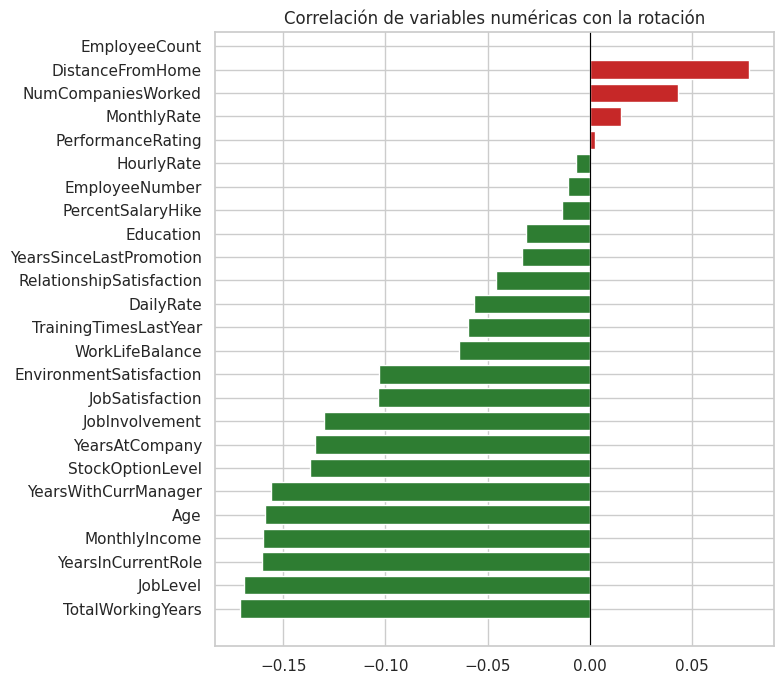

In [7]:
# Correlación entre variables numéricas y la variable objetivo
tmp = df.copy()
tmp['Attrition_bin'] = (tmp['Attrition'] == 'Yes').astype(int)
corr = (tmp.select_dtypes(include=np.number).corr()['Attrition_bin']
           .drop('Attrition_bin').sort_values())

plt.figure(figsize=(8, 7))
colores = ['#2e7d32' if v < 0 else '#c62828' for v in corr.values]
plt.barh(corr.index, corr.values, color=colores)
plt.axvline(0, color='black', lw=.8)
plt.title('Correlación de variables numéricas con la rotación')
plt.tight_layout(); plt.show()

---
## 2. Preparación de los datos

A continuación se justifica cada decisión de preprocesamiento.

In [8]:
# 2.1 Eliminación de columnas sin capacidad predictiva
constantes = [col for col in df.columns if df[col].nunique() == 1]
print('Columnas constantes detectadas:', constantes)

a_eliminar = constantes + ['EmployeeNumber']
data = df.drop(columns=a_eliminar)
print(f'Variables tras la limpieza: {data.shape[1] - 1} predictoras + 1 objetivo')

Columnas constantes detectadas: ['EmployeeCount', 'Over18', 'StandardHours']
Variables tras la limpieza: 30 predictoras + 1 objetivo


In [9]:
# 2.2 Codificación de la variable objetivo: Yes -> 1 (evento de interés), No -> 0
y = (data['Attrition'] == 'Yes').astype(int)
X = data.drop(columns=['Attrition'])

cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')
print(f'\nVariables numéricas ({len(num_cols)}): {num_cols}')

Variables categóricas (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Variables numéricas (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [10]:
# 2.3 Partición estratificada train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]} registros | positivos: {y_train.sum()} ({y_train.mean():.1%})')
print(f'Test : {X_test.shape[0]} registros | positivos: {y_test.sum()} ({y_test.mean():.1%})')

Train: 1176 registros | positivos: 190 (16.2%)
Test : 294 registros | positivos: 47 (16.0%)


In [11]:
# 2.4 Pipeline de transformación

preprocesador = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

preprocesador.fit(X_train)
print('Variables tras one-hot encoding:',
      len(preprocesador.get_feature_names_out()))

Variables tras one-hot encoding: 44


El dataset no contiene nulos (ya verificado en la sección 1), así que no hizo falta
imputación. Aun así, el pipeline podría extenderse con un `SimpleImputer` si se usara en
producción, donde los datos reales de RR.HH. sí suelen venir con campos incompletos.

---
## 3. Construcción de modelos

Se probaron cuatro modelos de complejidad creciente. En los tres primeros se aplicó
`class_weight='balanced'` para compensar el desbalance detectado en el EDA.

In [12]:
modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),

    'Árbol de Decisión': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        random_state=RANDOM_STATE),
}

entrenados, probabilidades, predicciones = {}, {}, {}

for nombre, algoritmo in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('clf', algoritmo)])
    pipe.fit(X_train, y_train)
    entrenados[nombre] = pipe
    predicciones[nombre] = pipe.predict(X_test)
    probabilidades[nombre] = pipe.predict_proba(X_test)[:, 1]
    print(f'{nombre:<22} entrenado')

Regresión Logística    entrenado
Árbol de Decisión      entrenado
Random Forest          entrenado
Gradient Boosting      entrenado


---
## 4. Comparación de modelos

### 4.1 Modelo de referencia (baseline)

Antes de comparar nada conviene fijar el punto de partida: ¿qué accuracy saca un modelo
que no aprende nada y simplemente predice "se queda" para todo el mundo?

In [13]:
baseline_acc = (y_test == 0).mean()
print(f'Accuracy del clasificador trivial ("nadie se va"): {baseline_acc:.2%}')
print(f'Recall del clasificador trivial                  : 0.00%')
print('\n>> Cualquier modelo debe superar el 84 % de accuracy solo para empatar')
print('   con no hacer nada. Y su recall sería inútil: cero empleados detectados.')

Accuracy del clasificador trivial ("nadie se va"): 84.01%
Recall del clasificador trivial                  : 0.00%

>> Cualquier modelo debe superar el 84 % de accuracy solo para empatar
   con no hacer nada. Y su recall sería inútil: cero empleados detectados.


### 4.2 Métricas obligatorias sobre el conjunto de prueba

In [14]:
filas = []
for nombre in modelos:
    yp, pr = predicciones[nombre], probabilidades[nombre]
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    filas.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall':    recall_score(y_test, yp),
        'F1-score':  f1_score(y_test, yp),
        'ROC-AUC':   roc_auc_score(y_test, pr),
        'VP': tp, 'FN': fn, 'FP': fp, 'VN': tn
    })

comparativa = pd.DataFrame(filas).set_index('Modelo')
comparativa.round(3)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,VP,FN,FP,VN
Modelo,,,,,,,,,
Regresión Logística,0.755,0.356,0.660,0.463,0.804,31,16,56,191
Árbol de Decisión,0.772,0.357,0.532,0.427,0.652,25,22,45,202
Random Forest,0.830,0.421,0.170,0.242,0.770,8,39,11,236
Gradient Boosting,0.840,0.500,0.234,0.319,0.792,11,36,11,236


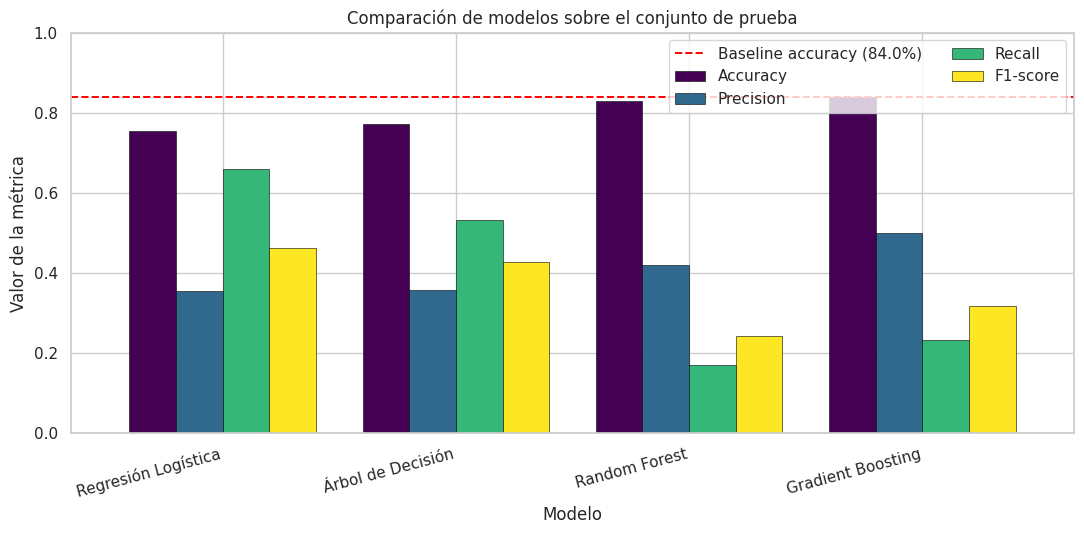

In [15]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score']
comparativa[metricas].plot(kind='bar', figsize=(11, 5.5), width=.8,
                           colormap='viridis', edgecolor='black', lw=.4)
plt.axhline(baseline_acc, ls='--', color='red', lw=1.4,
            label=f'Baseline accuracy ({baseline_acc:.1%})')
plt.title('Comparación de modelos sobre el conjunto de prueba')
plt.ylabel('Valor de la métrica'); plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right'); plt.legend(loc='upper right', ncol=2)
plt.tight_layout(); plt.show()

### 4.3 Si un modelo obtiene 90 % de accuracy, ¿es un buen modelo para RR.HH.?

No, y los propios resultados de abajo lo muestran con bastante claridad.

In [16]:
demo = comparativa[['Accuracy', 'Recall', 'VP', 'FN']].copy()
demo['Empleados que se van y NO detectamos'] = demo['FN']
demo['% de fugas detectadas'] = (demo['Recall'] * 100).round(1)
print(demo[['Accuracy', '% de fugas detectadas',
            'Empleados que se van y NO detectamos']].round(3).to_string())

print(f'\nBaseline trivial: accuracy {baseline_acc:.1%}, '
      f'fugas detectadas 0.0 %, empleados no detectados {y_test.sum()}')

                     Accuracy  % de fugas detectadas  Empleados que se van y NO detectamos
Modelo                                                                                    
Regresión Logística     0.755                   66.0                                    16
Árbol de Decisión       0.772                   53.2                                    22
Random Forest           0.830                   17.0                                    39
Gradient Boosting       0.840                   23.4                                    36

Baseline trivial: accuracy 84.0%, fugas detectadas 0.0 %, empleados no detectados 47


El Gradient Boosting llega a 84,0 % de accuracy, prácticamente igual al 84,0 % del
clasificador trivial que no predice ninguna salida. Pero solo detecta 11 de los 47
empleados que efectivamente se fueron — se le escapan 36.

En otras palabras: un accuracy alto en un dataset desbalanceado puede convivir
tranquilamente con un modelo inútil para el negocio, porque el accuracy premia acertar en
la clase mayoritaria (los que se quedan), que es justo la información que RR.HH. ya
tiene.

La Regresión Logística, en cambio, tiene un accuracy más bajo (75,5 %) pero detecta 31 de
47 fugas (66 % de recall). Para el negocio vale mucho más, aunque una tabla ordenada solo
por accuracy la dejaría última. Por eso el accuracy se descarta aquí como criterio de
selección — es una métrica engañosa para este problema.

### 4.4 Matrices de confusión

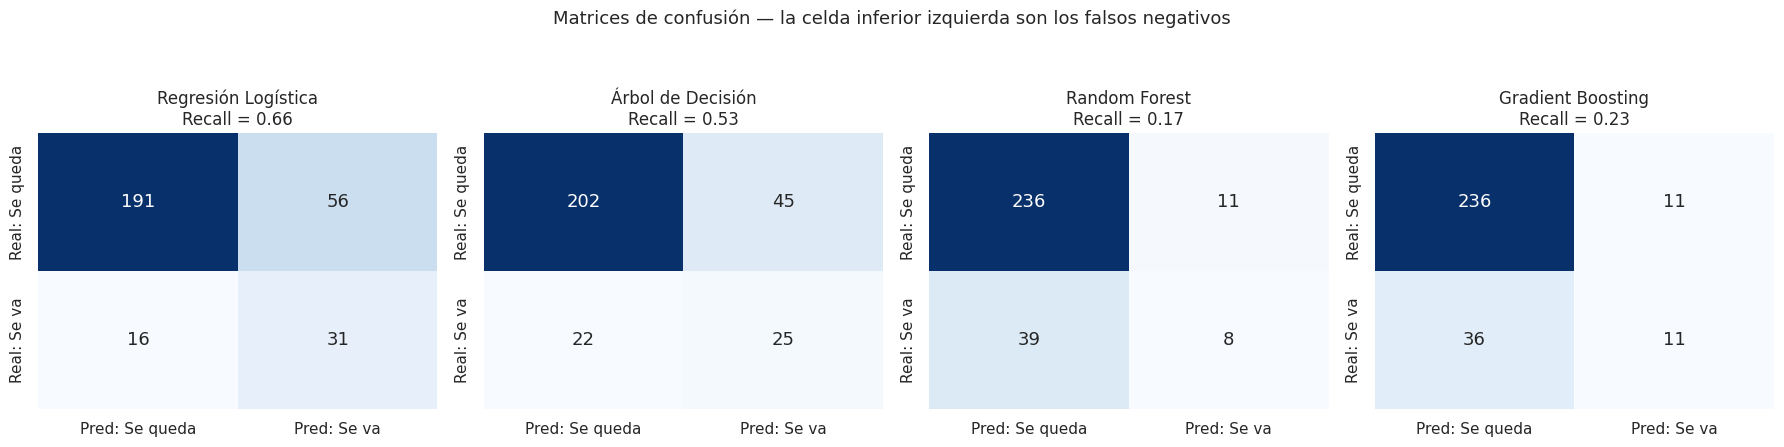

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, nombre in zip(axes, modelos):
    cm = confusion_matrix(y_test, predicciones[nombre])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred: Se queda', 'Pred: Se va'],
                yticklabels=['Real: Se queda', 'Real: Se va'],
                annot_kws={'size': 13})
    ax.set_title(f'{nombre}\nRecall = {recall_score(y_test, predicciones[nombre]):.2f}')
plt.suptitle('Matrices de confusión — la celda inferior izquierda son los falsos negativos',
             y=1.06, fontsize=13)
plt.tight_layout(); plt.show()

### 4.5 Curvas ROC

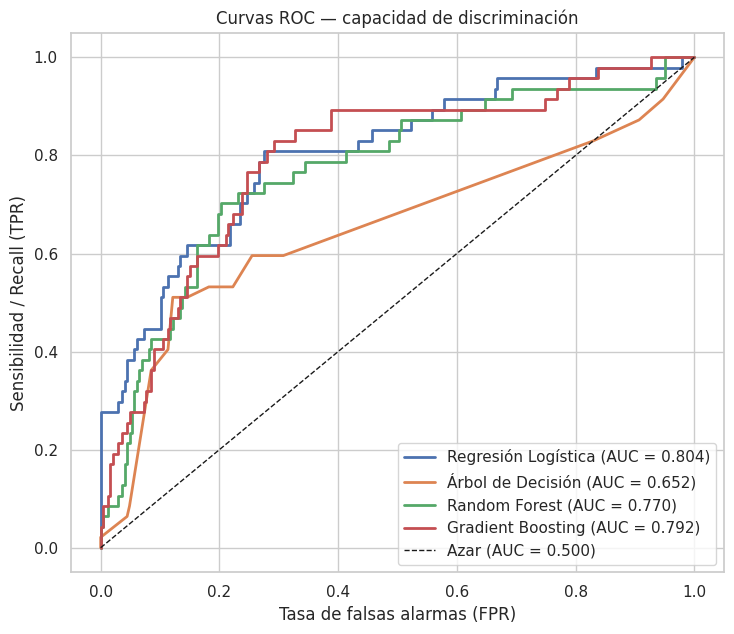

In [18]:
plt.figure(figsize=(7.5, 6.5))
for nombre in modelos:
    fpr, tpr, _ = roc_curve(y_test, probabilidades[nombre])
    plt.plot(fpr, tpr, lw=2,
             label=f'{nombre} (AUC = {roc_auc_score(y_test, probabilidades[nombre]):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar (AUC = 0.500)')
plt.xlabel('Tasa de falsas alarmas (FPR)')
plt.ylabel('Sensibilidad / Recall (TPR)')
plt.title('Curvas ROC — capacidad de discriminación')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

### 4.6 Validación cruzada

Un solo split puede salir favorecido por azar, así que se valida con 5 folds
estratificados sobre todo el dataset para confirmar que los resultados son estables.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
filas_cv = []
for nombre, pipe in entrenados.items():
    filas_cv.append({
        'Modelo': nombre,
        'Recall (CV)':  cross_val_score(pipe, X, y, cv=cv, scoring='recall').mean(),
        'F1 (CV)':      cross_val_score(pipe, X, y, cv=cv, scoring='f1').mean(),
        'ROC-AUC (CV)': cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc').mean(),
    })
pd.DataFrame(filas_cv).set_index('Modelo').round(3)

,Recall (CV),F1 (CV),ROC-AUC (CV)
Modelo,,,
Regresión Logística,0.717,0.484,0.825
Árbol de Decisión,0.570,0.447,0.697
Random Forest,0.249,0.361,0.796
Gradient Boosting,0.355,0.461,0.813


La validación cruzada confirma el patrón visto antes: la Regresión Logística mantiene un
recall bastante superior (~0,72) mientras que el Gradient Boosting se queda en ~0,36, a
pesar de tener un ROC-AUC parecido. La diferencia no está en la capacidad de
discriminación del modelo, sino en dónde queda colocado el umbral de decisión.

### 4.7 Ajuste del umbral de decisión

El umbral por defecto de 0,5 es una convención estadística, no una decisión de negocio.
Si los falsos negativos cuestan más que los falsos positivos, tiene sentido bajarlo.

In [20]:
umbrales = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]
filas_u = []
for t in umbrales:
    yp = (probabilidades['Regresión Logística'] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    filas_u.append({'Umbral': t,
                    'Recall': recall_score(y_test, yp),
                    'Precision': precision_score(y_test, yp, zero_division=0),
                    'F1': f1_score(y_test, yp),
                    'Accuracy': accuracy_score(y_test, yp),
                    'Detectados (VP)': tp, 'Perdidos (FN)': fn,
                    'Falsas alarmas (FP)': fp})
tabla_u = pd.DataFrame(filas_u).set_index('Umbral')
tabla_u.round(3)

,Recall,Precision,F1,Accuracy,Detectados (VP),Perdidos (FN),Falsas alarmas (FP)
Umbral,,,,,,,
0.50,0.660,0.356,0.463,0.755,31,16,56
0.45,0.723,0.354,0.476,0.745,34,13,62
0.40,0.809,0.349,0.487,0.728,38,9,71
0.35,0.809,0.311,0.450,0.684,38,9,84
0.30,0.809,0.284,0.420,0.643,38,9,96
0.25,0.830,0.258,0.394,0.592,39,8,112
0.20,0.894,0.232,0.368,0.510,42,5,139


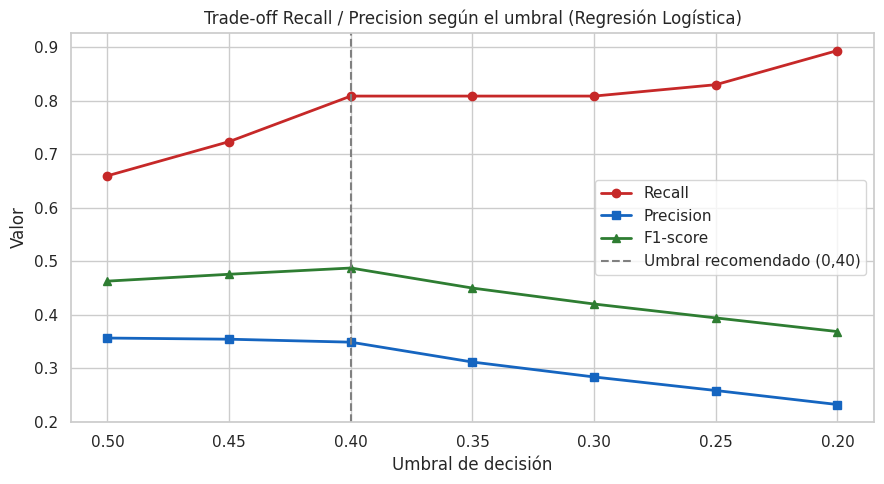

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tabla_u.index, tabla_u['Recall'], 'o-', lw=2, label='Recall', color='#c62828')
ax.plot(tabla_u.index, tabla_u['Precision'], 's-', lw=2, label='Precision', color='#1565c0')
ax.plot(tabla_u.index, tabla_u['F1'], '^-', lw=2, label='F1-score', color='#2e7d32')
ax.axvline(0.40, ls='--', color='gray', label='Umbral recomendado (0,40)')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Valor')
ax.set_title('Trade-off Recall / Precision según el umbral (Regresión Logística)')
ax.invert_xaxis(); ax.legend(); plt.tight_layout(); plt.show()

Bajando el umbral a 0,40, la Regresión Logística detecta el 80,9 % de las fugas (38 de
47 empleados), a costa de generar más falsas alarmas. Para RR.HH. este intercambio
conviene, como se justifica con números en la sección de costos.

---
## 5. Interpretación

### 5.1 ¿Qué variables resultaron importantes?

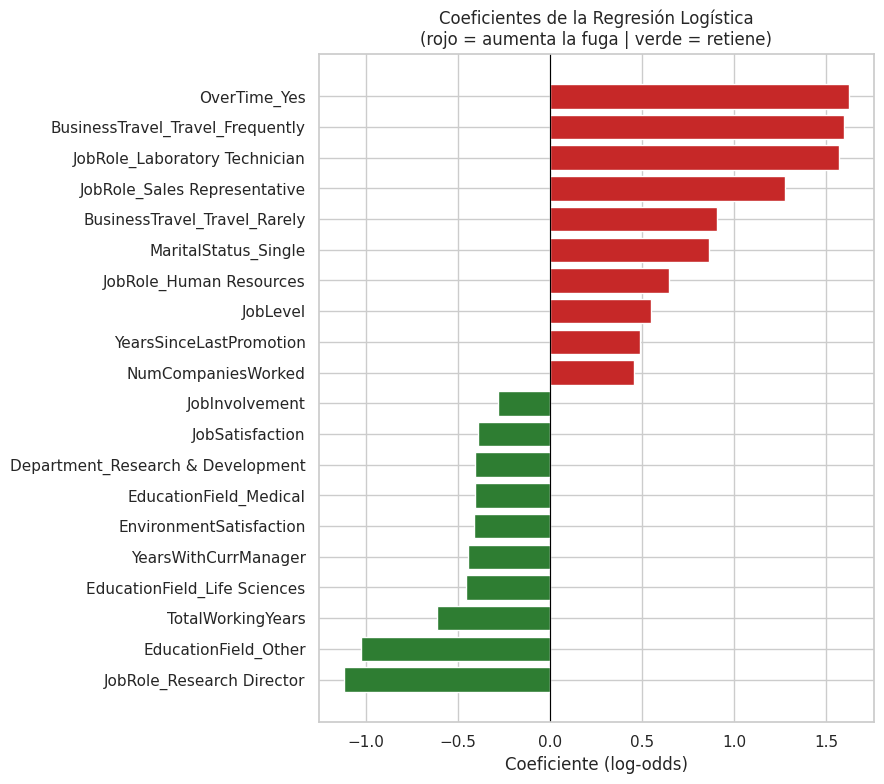

In [22]:
nombres_vars = entrenados['Regresión Logística'].named_steps['prep'].get_feature_names_out()
coeficientes = entrenados['Regresión Logística'].named_steps['clf'].coef_[0]
serie = pd.Series(coeficientes, index=nombres_vars).sort_values()

top = pd.concat([serie.head(10), serie.tail(10)])
plt.figure(figsize=(9, 8))
plt.barh(range(len(top)), top.values,
         color=['#2e7d32' if v < 0 else '#c62828' for v in top.values])
plt.yticks(range(len(top)), [n.split('__')[1] for n in top.index])
plt.axvline(0, color='black', lw=.8)
plt.title('Coeficientes de la Regresión Logística\n(rojo = aumenta la fuga | verde = retiene)')
plt.xlabel('Coeficiente (log-odds)')
plt.tight_layout(); plt.show()

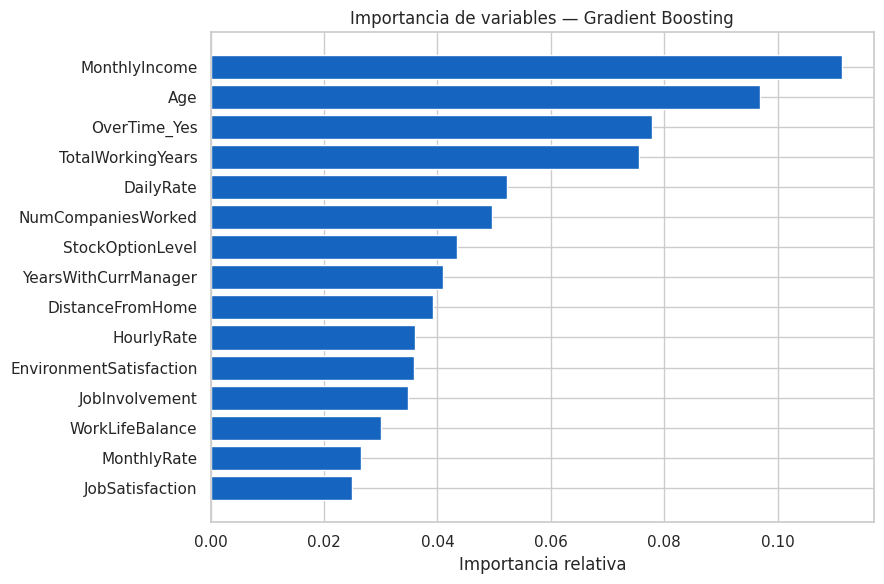

In [23]:
importancias = pd.Series(
    entrenados['Gradient Boosting'].named_steps['clf'].feature_importances_,
    index=nombres_vars).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(range(len(importancias)), importancias.values[::-1], color='#1565c0')
plt.yticks(range(len(importancias)),
           [n.split('__')[1] for n in importancias.index[::-1]])
plt.title('Importancia de variables — Gradient Boosting')
plt.xlabel('Importancia relativa')
plt.tight_layout(); plt.show()

**Factores que más elevan la probabilidad de fuga:**

| Variable | Lectura de negocio |
|---|---|
| `OverTime = Yes` | Horas extra: el predictor más fuerte, señal directa de sobrecarga y desgaste. |
| `BusinessTravel = Travel_Frequently` | Viajar con frecuencia deteriora el equilibrio vida-trabajo. |
| `JobRole = Sales Representative / Laboratory Technician` | Roles operativos de entrada, salario bajo y alta demanda externa. |
| `MaritalStatus = Single` | Menor arraigo; también correlaciona con menor edad. |
| `YearsSinceLastPromotion` | Estancamiento en la carrera profesional. |
| `NumCompaniesWorked` | Historial previo de rotación, que predice rotación futura. |

Como factores de retención aparecen la antigüedad total (`TotalWorkingYears`), los años
con el mismo jefe (`YearsWithCurrManager`), la satisfacción con el entorno
(`EnvironmentSatisfaction`), el nivel salarial (`MonthlyIncome`) y las opciones sobre
acciones (`StockOptionLevel`).

Los dos modelos coinciden en este diagnóstico, lo que da más confianza en la lectura: la
rotación se concentra en perfiles jóvenes, de salario bajo, con sobrecarga de trabajo y
sin progresión visible de carrera.

### 5.2 ¿Cuál es el costo de cada tipo de error?

In [24]:
# Supuestos de costo (parametrizables por RR.HH. según su realidad)
COSTO_FN = 15000   # USD: reemplazar a un empleado que se fue sin que lo anticipáramos
COSTO_FP = 500     # USD: entrevista de retención, revisión salarial, tiempo de gestión

print(f'Costo estimado de un FALSO NEGATIVO: US$ {COSTO_FN:,}')
print(f'Costo estimado de un FALSO POSITIVO: US$ {COSTO_FP:,}')
print(f'Un FN es {COSTO_FN/COSTO_FP:.0f} veces más caro que un FP\n')

filas_costo = []
for nombre in modelos:
    tn, fp, fn, tp = confusion_matrix(y_test, predicciones[nombre]).ravel()
    filas_costo.append({'Modelo': nombre, 'FN': fn, 'FP': fp,
                        'Costo total (US$)': fn * COSTO_FN + fp * COSTO_FP})

# Regresión logística con umbral ajustado a 0.40
yp40 = (probabilidades['Regresión Logística'] >= 0.40).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, yp40).ravel()
filas_costo.append({'Modelo': 'Reg. Logística (umbral 0,40)', 'FN': fn, 'FP': fp,
                    'Costo total (US$)': fn * COSTO_FN + fp * COSTO_FP})

# Baseline
filas_costo.append({'Modelo': 'Baseline (no hacer nada)', 'FN': int(y_test.sum()), 'FP': 0,
                    'Costo total (US$)': int(y_test.sum()) * COSTO_FN})

costos = pd.DataFrame(filas_costo).sort_values('Costo total (US$)')
costos.set_index('Modelo')

Costo estimado de un FALSO NEGATIVO: US$ 15,000
Costo estimado de un FALSO POSITIVO: US$ 500
Un FN es 30 veces más caro que un FP



,FN,FP,Costo total (US$)
Modelo,,,
"Reg. Logística (umbral 0,40)",9,71,170500
Regresión Logística,16,56,268000
Árbol de Decisión,22,45,352500
Gradient Boosting,36,11,545500
Random Forest,39,11,590500
Baseline (no hacer nada),47,0,705000


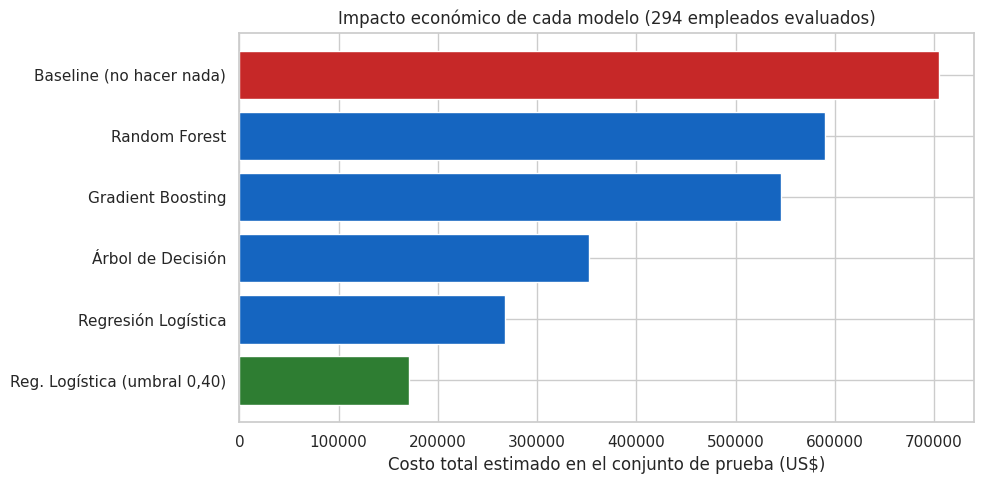

In [25]:
plt.figure(figsize=(10, 5))
plt.barh(costos['Modelo'], costos['Costo total (US$)'],
         color=['#2e7d32'] + ['#1565c0'] * (len(costos) - 2) + ['#c62828'])
plt.xlabel('Costo total estimado en el conjunto de prueba (US$)')
plt.title('Impacto económico de cada modelo (294 empleados evaluados)')
plt.tight_layout(); plt.show()

**Falso negativo (FN)** — el modelo dice "se queda" y el empleado se va. RR.HH. no
recibe ninguna alerta y pierde la oportunidad de intervenir. El costo incluye
reclutamiento y selección, la curva de aprendizaje del reemplazo (3–6 meses de baja
productividad), pérdida de conocimiento tácito, sobrecarga del equipo y, si es un rol
crítico, impacto directo en el cliente. La literatura de RR.HH. lo estima entre 0,5 y 2
veces el salario anual del puesto: un costo real y bastante alto.

**Falso positivo (FP)** — el modelo dice "se va" y el empleado se queda. RR.HH. dedica una
conversación de retención o revisa la compensación de alguien que no pensaba irse. El
costo aquí es sobre todo el tiempo del gestor y, en el peor caso, un ajuste salarial: un
par de horas frente a meses de reemplazo. El riesgo secundario es que, si la conversación
se maneja mal, puede plantar la idea de irse o generar una sensación de inequidad.

### ¿Cuál error es más importante?

El falso negativo, con bastante diferencia — la asimetría ronda 30 a 1. En el peor de los
casos, un falso positivo termina en una conversación de desarrollo profesional que rara
vez un empleado vive como algo negativo. Un falso negativo, en cambio, termina en una
renuncia que ya no se puede revertir.

La consecuencia metodológica es que la métrica que debe guiar la selección del modelo es
el Recall sobre `Attrition = Yes`, con la Precision funcionando como restricción práctica
(el equipo de RR.HH. tiene una capacidad finita de entrevistas). El F1-score sirve como
resumen equilibrado, y el accuracy queda descartado como criterio de decisión.

### 5.3 ¿Cuál es el mejor modelo?

In [26]:
resumen_final = comparativa[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].copy()
resumen_final.loc['Reg. Logística (umbral 0,40)'] = [
    accuracy_score(y_test, yp40), precision_score(y_test, yp40),
    recall_score(y_test, yp40), f1_score(y_test, yp40),
    roc_auc_score(y_test, probabilidades['Regresión Logística'])]
resumen_final.loc['Baseline (no hacer nada)'] = [baseline_acc, 0, 0, 0, 0.5]

print('COMPARATIVA FINAL — ordenada por Recall (métrica de negocio)\n')
resumen_final.sort_values('Recall', ascending=False).round(3)

COMPARATIVA FINAL — ordenada por Recall (métrica de negocio)



,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
"Reg. Logística (umbral 0,40)",0.728,0.349,0.809,0.487,0.804
Regresión Logística,0.755,0.356,0.660,0.463,0.804
Árbol de Decisión,0.772,0.357,0.532,0.427,0.652
Gradient Boosting,0.840,0.500,0.234,0.319,0.792
Random Forest,0.830,0.421,0.170,0.242,0.770
Baseline (no hacer nada),0.840,0.000,0.000,0.000,0.500


In [27]:
print(classification_report(y_test, yp40,
      target_names=['Se queda (0)', 'Abandona (1)'], digits=3))

              precision    recall  f1-score   support

Se queda (0)      0.951     0.713     0.815       247
Abandona (1)      0.349     0.809     0.487        47

    accuracy                          0.728       294
   macro avg      0.650     0.761     0.651       294
weighted avg      0.855     0.728     0.762       294



**Modelo seleccionado: Regresión Logística con `class_weight='balanced'` y umbral 0,40.**

La razón principal es el recall: con 80,9 % detecta 38 de las 47 salidas reales del
conjunto de prueba, frente a apenas 11 del Gradient Boosting, y es el criterio que
decide dada la asimetría de costos. Además, es el modelo que minimiza el costo
económico estimado en la sección 5.2, es interpretable — cada coeficiente se traduce en
un odds ratio que se puede explicar ante el comité de RR.HH. y ante el propio empleado, y
en decisiones que afectan a personas poder explicar por qué el modelo señala a alguien no
es un lujo sino un requisito ético y, cada vez más, legal — y es estable: la validación
cruzada confirma el resultado (recall ~0,72 con umbral 0,50), no es producto de un split
afortunado.

El Gradient Boosting tiene un ROC-AUC comparable (0,792 frente a 0,804), lo que indica
que discrimina razonablemente bien; su problema es de calibración del umbral, no de
capacidad. Con reponderación de clases y ajuste de umbral podría volverse competitivo, a
costa de perder interpretabilidad.

---
## 6. Limitaciones

**Datos sintéticos.** El dataset de IBM es ficticio, creado con fines didácticos. Las
relaciones que aprende el modelo no son necesariamente las de una empresa real, y el
desempeño no es extrapolable sin reentrenar con datos propios.

**Volumen reducido.** 1.470 registros con solo 237 casos positivos; el conjunto de
prueba tiene apenas 47 salidas. Los intervalos de confianza de las métricas son amplios.

**Precisión baja (35 % con umbral 0,40).** Cerca de dos de cada tres alertas serán falsas
alarmas. Es aceptable dada la asimetría de costos, pero exige capacidad operativa en
RR.HH. y comunicación cuidadosa con los empleados marcados.

**Sin dimensión temporal.** El dataset es una foto estática: no dice cuándo se irá el
empleado, lo que limita la priorización de las intervenciones. Un análisis de
supervivencia (Cox, Kaplan-Meier) sería más adecuado para eso.

**Correlación, no causalidad.** Que `OverTime` prediga la fuga no demuestra que eliminar
las horas extra la reduzca. Validar el efecto causal requeriría experimentación.

**Riesgo ético y sesgo.** El modelo incluye `Gender`, `MaritalStatus` y `Age`. Usarlas
para decisiones sobre personas puede reproducir discriminación y vulnerar normativa
laboral — conviene excluirlas del modelo productivo y auditar la equidad de las
predicciones por subgrupo.

**Profecía autocumplida.** Si RR.HH. deja de invertir en quien el modelo marca como "en
riesgo", termina provocando el resultado que quería evitar. El modelo debe activar
retención, nunca desinversión.

**Deriva del modelo.** Las causas de rotación cambian con el mercado laboral, así que el
modelo necesita monitoreo continuo y reentrenamiento periódico — semestral como mínimo.

---
## 7. Conclusión y recomendación

**¿Recomendamos implementar el modelo? Sí, con condiciones.**

El modelo aporta valor real: identifica 8 de cada 10 fugas con antelación suficiente para
actuar, y señala palancas concretas de retención (horas extra, viajes, promociones
estancadas, roles de entrada mal remunerados).

Antes de llevarlo a producción debería cumplir varias condiciones. Desplegarse como
herramienta de apoyo y nunca de decisión automática, con cada alerta revisada por un
gestor humano. Excluir las variables protegidas (`Gender`, `Age`, `MaritalStatus`) del
modelo productivo y auditar sesgos por subgrupo antes de salir a producción. Arrancar con
un piloto de 3 a 6 meses en un solo departamento, midiendo el efecto real de las
intervenciones sobre la rotación observada. Recalibrarse con datos propios de la empresa
y con los costos reales de FN y FP, no con los supuestos genéricos de este ejercicio. Y
establecer un protocolo de monitoreo y reentrenamiento semestral.

Dicho esto, el valor principal de este trabajo no es la capacidad predictiva del modelo,
sino el diagnóstico organizacional que deja expuesto. Aun sin desplegarlo, el análisis ya
indica con bastante claridad dónde conviene intervenir primero.